Zadanie 1. Implementacja PCA z wykorzystaniem Scikit-Learn (zestaw danych z zadania 
wprowadzającego).

In [18]:
import cv2
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score

In [44]:
data = pd.read_csv('data.csv')
data.head()
print(data.describe())
print(data.isnull().sum())
print(data.dtypes)

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

1.1.  Wstępne przetworzenie danych oraz standaryzacja.  

In [20]:
data_cleaned = data.drop(columns=['id', 'Unnamed: 32'])

# Convert 'diagnosis' to numeric values (0 for benign, 1 for malignant)
data_cleaned['diagnosis'] = data_cleaned['diagnosis'].map({'B': 0, 'M': 1})

# Separate features and target
X = data_cleaned.drop(columns=['diagnosis'])
y = data_cleaned['diagnosis']

# Standardize the feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a standardized DataFrame for visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the standardized data
X_scaled_df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


1.2.  Redukcja wymiarowości do dwóch wymiarów. 

In [21]:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert the results into a DataFrame for better visualization
X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['diagnosis'] = y

# Display the first few rows of the PCA result
X_pca_df.head()

,PCA1,PCA2,diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


##### 1.3.  Dopasowanie transformatora i uzyskanie składowych głównych: 
##### Dopasowanie transformatora PCA do danych – przekształcenie oryginalnych danych na  dwie  główne  składowe,  rzutując  je  na  wektory  własne  odpowiadające  dwóm największym wartościom własnym.

In [22]:
# Explained variance ratio for the two components
explained_variance_ratio = pca.explained_variance_ratio_

# Principal eigenvectors (components)
principal_components = pca.components_

explained_variance_ratio, principal_components

(array([0.44272026, 0.18971182]),
 array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
          0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
          0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
          0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
          0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
          0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
        [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
          0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
         -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
          0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
         -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
          0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]]))

##### 1.4.  Wizualizacja głównych składowych: 
##### Wykres punktowy z kolumną 'Target': dodaj kolory lub znaczniki według wartości kolumny „Target”, aby sprawdzić, jak dobrze składowe główne rozróżniają klasy.

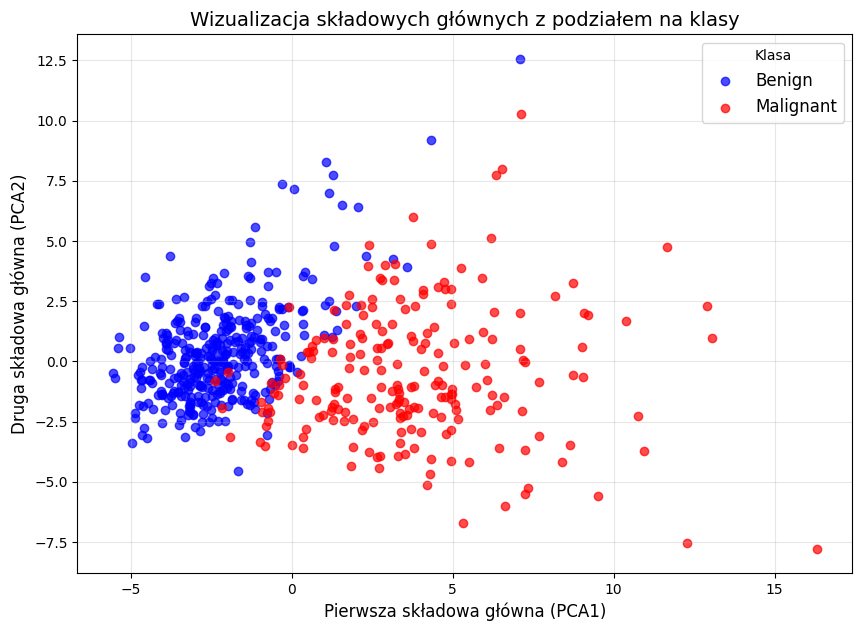

In [23]:
plt.figure(figsize=(10, 7))
colors = ['blue', 'red']
targets = [0, 1]  # 0 - Benign, 1 - Malignant
labels = ['Benign', 'Malignant']

for target, color, label in zip(targets, colors, labels):
    subset = X_pca_df[X_pca_df['diagnosis'] == target]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=label, alpha=0.7, c=color)

plt.title('Wizualizacja składowych głównych z podziałem na klasy', fontsize=14)
plt.xlabel('Pierwsza składowa główna (PCA1)', fontsize=12)
plt.ylabel('Druga składowa główna (PCA2)', fontsize=12)
plt.legend(title='Klasa', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

##### 1.5. Wyświetlenie składowych i zależności: 
##### 1.5.1. Atrybut components_ – po dopasowaniu transformatora należy wyświetlić atrybut components_,  aby  zobaczyć  macierz  składowych  głównych.  Składowe  te reprezentują wektory własne, które określają kierunki maksymalnej zmienności danych.

In [24]:
# Wyświetlenie macierzy składowych głównych (wektory własne)
components_df = pd.DataFrame(principal_components, columns=X.columns, index=['PCA1', 'PCA2'])

components_df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
PCA1,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
PCA2,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339


#### 1.5.2. Mapa cieplna – należy wykorzystać mapę cieplną do przedstawienia relacji między składowymi głównymi a oryginalnymi zmiennymi. Każda zmienna wejściowa (z 30-wymiarowego zbioru danych) jest reprezentowana w odniesieniu do głównych składowych. 

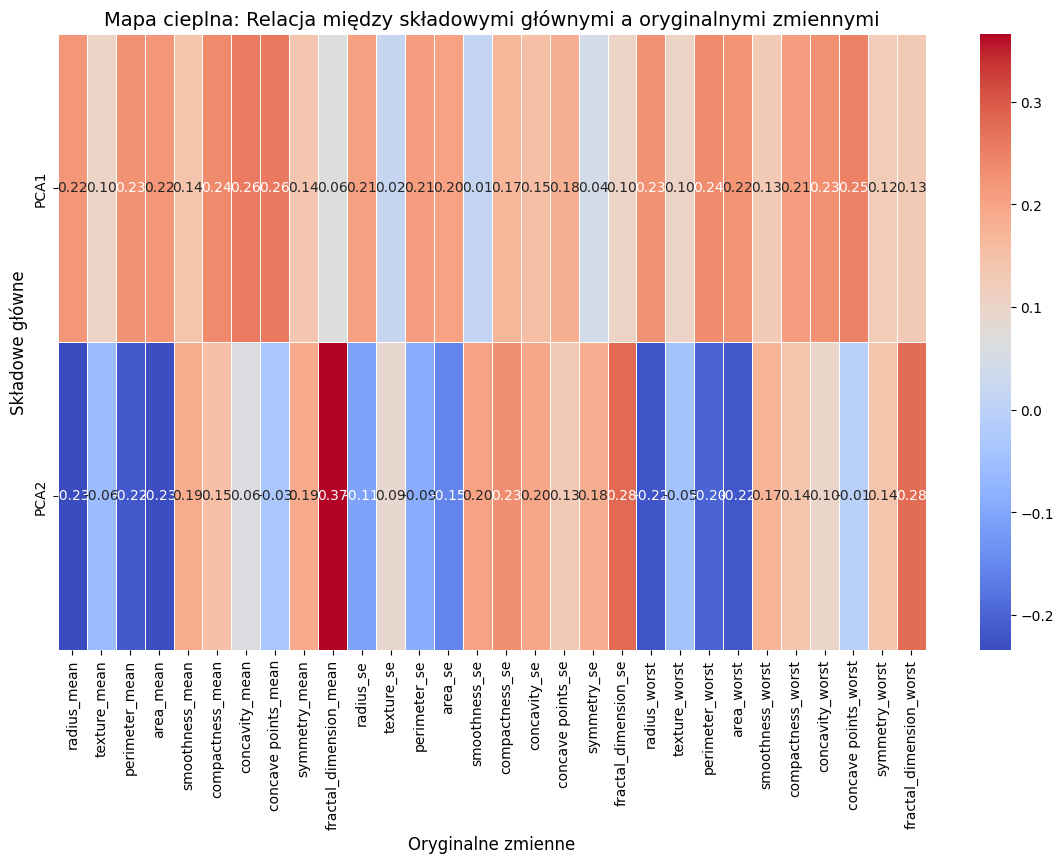

In [25]:
plt.figure(figsize=(14, 8))
sns.heatmap(components_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa cieplna: Relacja między składowymi głównymi a oryginalnymi zmiennymi', fontsize=14)
plt.xlabel('Oryginalne zmienne', fontsize=12)
plt.ylabel('Składowe główne', fontsize=12)
plt.show()

#### 1.6.  Analiza wariancji: 
#### 1.6.1. Wariancja składowych - jaki procent wariancji wyjaśniają poszczególne składowe (PC1 i PC2).

In [26]:
# Obliczenie procentowego udziału wyjaśnionej wariancji przez każdą składową
explained_variance_percentage = explained_variance_ratio * 100

# Przygotowanie danych do wyświetlenia
variance_analysis = pd.DataFrame({
    'Składowa': ['PCA1', 'PCA2'],
    'Procent wyjaśnionej wariancji': explained_variance_percentage
})
variance_analysis

,Składowa,Procent wyjaśnionej wariancji
0,PCA1,44.272026
1,PCA2,18.971182


1.6.2. Wariancja całkowita – jaki procent całkowitej wariancji danych jest wyjaśniany przez dwie wybrane składowe.

In [27]:
total_explained_variance = explained_variance_percentage.sum()

total_explained_variance

63.243207651559445

#### 1.6.3. Liczba składowych dla 95% i 99% wariancji – obliczenie liczby składowych, które pozwalają wyjaśnić ponad 905% i 99% całkowitej wariancji. 
#### 1.6.4. Wykres wariancji od liczby składowych – zobrazowanie zależności między liczbą składowych a wariancją, aby lepiej zrozumieć, jak szybko maleje wkład kolejnych składowych w całkowitą wariancję danych.

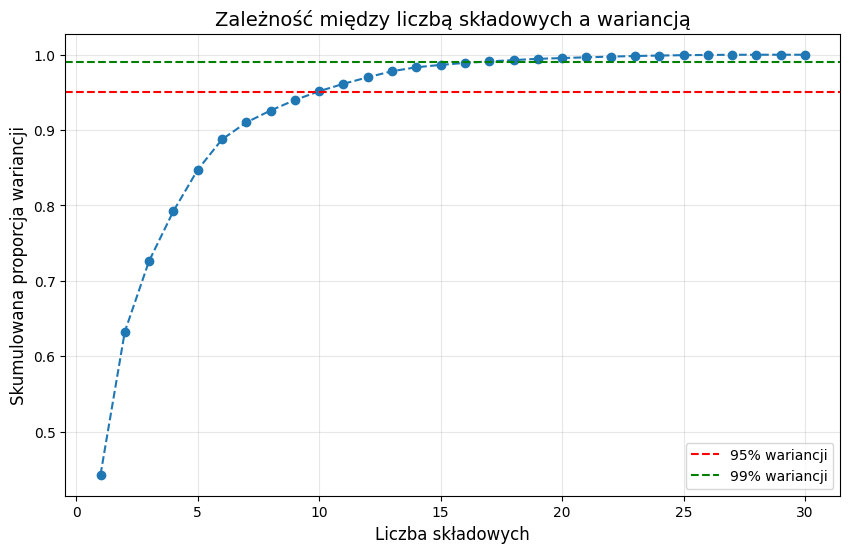

(10, 17)

In [28]:
# Obliczenie liczby składowych dla 95% i 99% wyjaśnionej wariancji
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance_ratio = pca_full.explained_variance_ratio_.cumsum()

# Liczba składowych dla 95% i 99% wariancji
n_components_95 = (cumulative_variance_ratio >= 0.95).argmax() + 1
n_components_99 = (cumulative_variance_ratio >= 0.99).argmax() + 1

# Przygotowanie danych do wykresu
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% wariancji')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% wariancji')
plt.title('Zależność między liczbą składowych a wariancją', fontsize=14)
plt.xlabel('Liczba składowych', fontsize=12)
plt.ylabel('Skumulowana proporcja wariancji', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

n_components_95, n_components_99

#### 1.7. Przeprowadzenie PCA na danych oryginalnych (pomijając standaryzację w kroku 2.1) i należy wykonać pozostałe kroki (od 2.2 do końca) na oryginalnych danych, aby porównać wpływ standaryzacji na wyniki PCA.

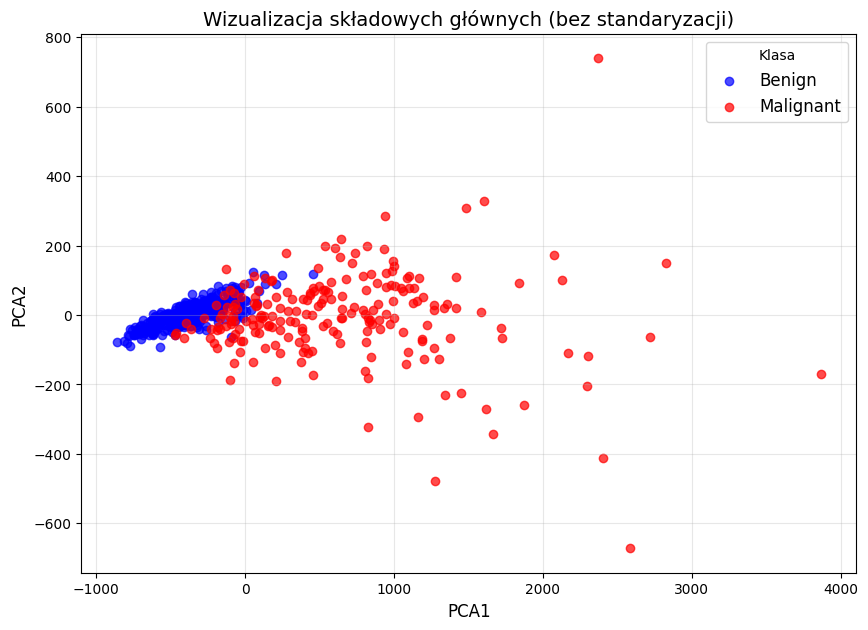


Macierz Składowych Głównych (bez standaryzacji):
      radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
PCA1     0.005086      0.002197        0.035076   0.516826         0.000004   
PCA2     0.009287     -0.002882        0.062748   0.851824        -0.000015   

      compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
PCA1          0.000041        0.000082             0.000048       0.000007   
PCA2         -0.000003        0.000075             0.000046      -0.000025   

      fractal_dimension_mean  ...  radius_worst  texture_worst  \
PCA1               -0.000003  ...      0.007155       0.003067   
PCA2               -0.000016  ...     -0.000569      -0.013215   

      perimeter_worst  area_worst  smoothness_worst  compactness_worst  \
PCA1         0.049458    0.852063          0.000006           0.000101   
PCA2        -0.000186   -0.519742         -0.000077          -0.000256   

      concavity_worst  concave points_worst  symmetry_w

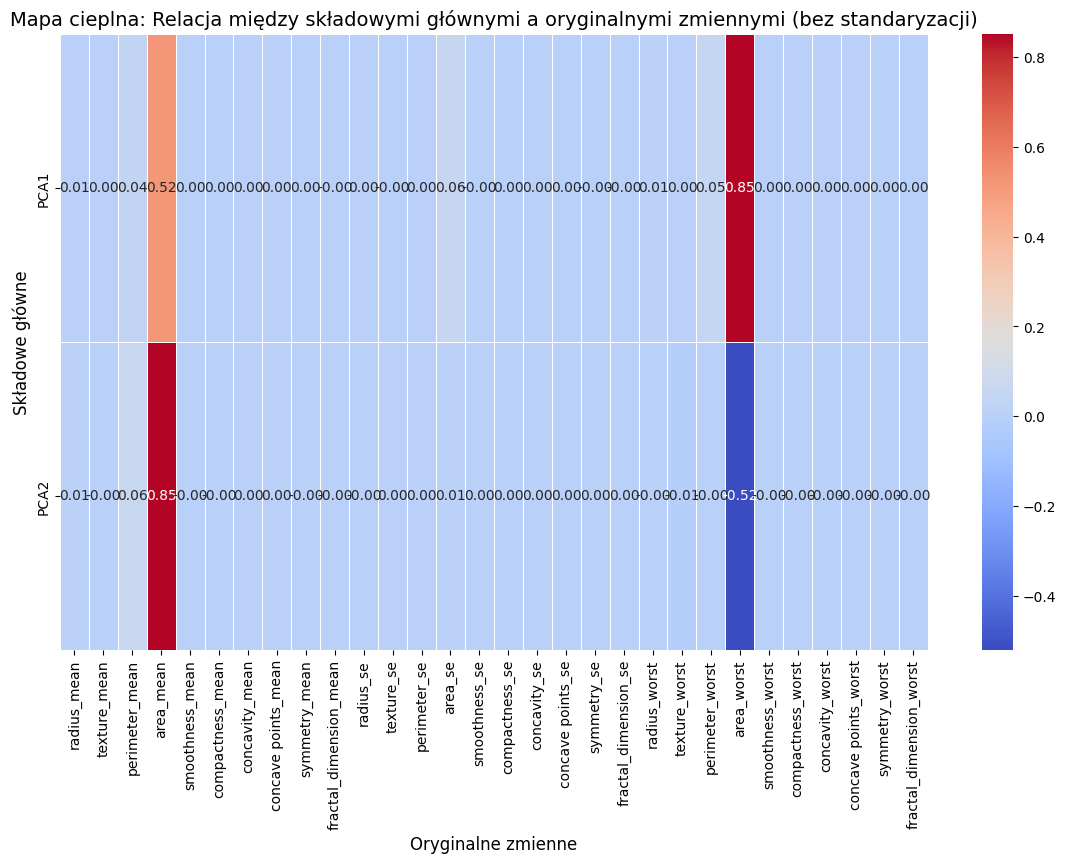

Wariancja wyjaśniona przez PCA1 (bez standaryzacji): 98.20%
Wariancja wyjaśniona przez PCA2 (bez standaryzacji): 1.62%
Wariancja wyjaśniona łącznie (bez standaryzacji): 99.82%
Liczba składowych dla 95% wariancji (bez standaryzacji): 1
Liczba składowych dla 99% wariancji (bez standaryzacji): 2


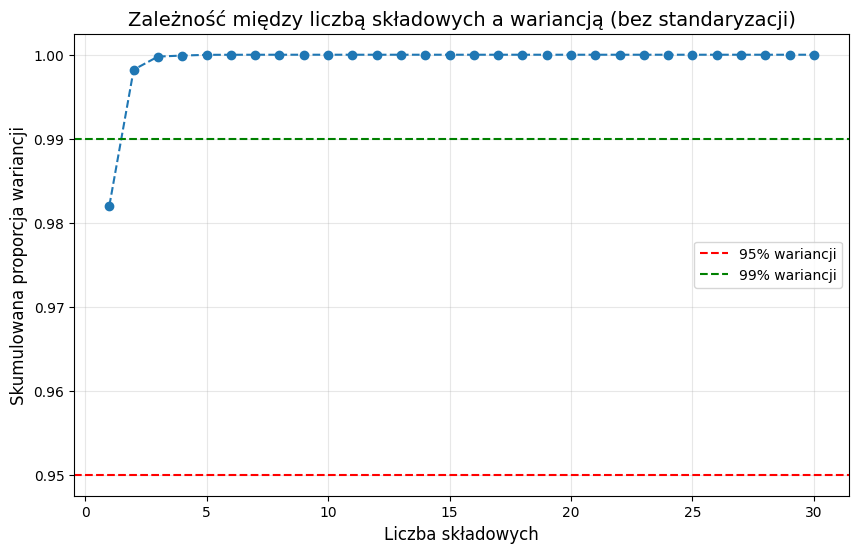

In [29]:
# 1.7 PCA bez standaryzacji
pca_no_scaling = PCA(n_components=2)
X_pca_no_scaling = pca_no_scaling.fit_transform(X)

# 1.2. Redukcja wymiarowości do dwóch wymiarów (bez standaryzacji)
explained_variance_ratio_no_scaling = pca_no_scaling.explained_variance_ratio_

# 1.3. Uzyskanie składowych głównych (bez standaryzacji)
principal_components_no_scaling = pca_no_scaling.components_

# 1.4. Wizualizacja głównych składowych (bez standaryzacji)
plt.figure(figsize=(10, 7))
for target, color, label in zip(targets, colors, labels):
    subset = pd.DataFrame(X_pca_no_scaling, columns=['PCA1', 'PCA2'])[y == target]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=label, alpha=0.7, c=color)

plt.title('Wizualizacja składowych głównych (bez standaryzacji)', fontsize=14)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)
plt.legend(title='Klasa', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# 1.5.1. Wyświetlenie macierzy składowych (bez standaryzacji)
components_df_no_scaling = pd.DataFrame(principal_components_no_scaling, columns=X.columns, index=['PCA1', 'PCA2'])
print("\nMacierz Składowych Głównych (bez standaryzacji):")
print(components_df_no_scaling)

# 1.5.2. Mapa cieplna (bez standaryzacji)
plt.figure(figsize=(14, 8))
sns.heatmap(components_df_no_scaling, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa cieplna: Relacja między składowymi głównymi a oryginalnymi zmiennymi (bez standaryzacji)', fontsize=14)
plt.xlabel('Oryginalne zmienne', fontsize=12)
plt.ylabel('Składowe główne', fontsize=12)
plt.show()

# 1.6. Analiza wariancji (bez standaryzacji)
explained_variance_percentage_no_scaling = explained_variance_ratio_no_scaling * 100
print(f"Wariancja wyjaśniona przez PCA1 (bez standaryzacji): {explained_variance_percentage_no_scaling[0]:.2f}%")
print(f"Wariancja wyjaśniona przez PCA2 (bez standaryzacji): {explained_variance_percentage_no_scaling[1]:.2f}%")
print(f"Wariancja wyjaśniona łącznie (bez standaryzacji): {explained_variance_percentage_no_scaling.sum():.2f}%")

# 1.6.3. Liczba składowych dla 95% i 99% wariancji (bez standaryzacji)
pca_full_no_scaling = PCA()
pca_full_no_scaling.fit(X)
cumulative_variance_ratio_no_scaling = pca_full_no_scaling.explained_variance_ratio_.cumsum()

n_components_95_no_scaling = (cumulative_variance_ratio_no_scaling >= 0.95).argmax() + 1
n_components_99_no_scaling = (cumulative_variance_ratio_no_scaling >= 0.99).argmax() + 1

print(f"Liczba składowych dla 95% wariancji (bez standaryzacji): {n_components_95_no_scaling}")
print(f"Liczba składowych dla 99% wariancji (bez standaryzacji): {n_components_99_no_scaling}")

# Wykres wariancji od liczby składowych (bez standaryzacji)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio_no_scaling) + 1), cumulative_variance_ratio_no_scaling, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% wariancji')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% wariancji')
plt.title('Zależność między liczbą składowych a wariancją (bez standaryzacji)', fontsize=14)
plt.xlabel('Liczba składowych', fontsize=12)
plt.ylabel('Skumulowana proporcja wariancji', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Zadanie 2. Implementacja analizy PCA dla danych obrazów cyfr. 
#### Proszę o pobranie danych ze źródła: digits.csv. Baza danych zawiera 250 obrazów cyfr o wymiarach 8x8 pikseli. 

In [30]:
data_digits = pd.read_csv('digits.csv')
data_digits.head()
# Sprawdzenie pierwszych kilku wierszy danych, aby zrozumieć strukturę
data_digits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pixel_0_0     1797 non-null   float64
 1   pixel_0_1     1797 non-null   float64
 2   pixel_0_2     1797 non-null   float64
 3   pixel_0_3     1797 non-null   float64
 4   pixel_0_4     1797 non-null   float64
 5   pixel_0_5     1797 non-null   float64
 6   pixel_0_6     1797 non-null   float64
 7   pixel_0_7     1797 non-null   float64
 8   pixel_1_0     1797 non-null   float64
 9   pixel_1_1     1797 non-null   float64
 10  pixel_1_2     1797 non-null   float64
 11  pixel_1_3     1797 non-null   float64
 12  pixel_1_4     1797 non-null   float64
 13  pixel_1_5     1797 non-null   float64
 14  pixel_1_6     1797 non-null   float64
 15  pixel_1_7     1797 non-null   float64
 16  pixel_2_0     1797 non-null   float64
 17  pixel_2_1     1797 non-null   float64
 18  pixel_2_2     1797 non-null 

#### 2.1. Przygotowanie danych: 
#### 2.1.1. Sprawdzenie kompletności danych.  
#### 2.1.2. Przygotowanie ramki danych piksele – utworzenie df_pixels. 
#### 2.1.3. Przykładowa  reprezentacja  obrazu  –  należy  pobrać  pierwszy  wiersz  danych  z obiektu df_pixels jako reprezentację jednego obrazu cyfry. 
#### 2.1.4. Wizualizacja obrazu – należy użyć Matplotlib lub Seaborn do wyświetlenia obrazu cyfry z odpowiednią mapą kolorów, aby zobaczyć graficzną reprezentację wartości pikseli.

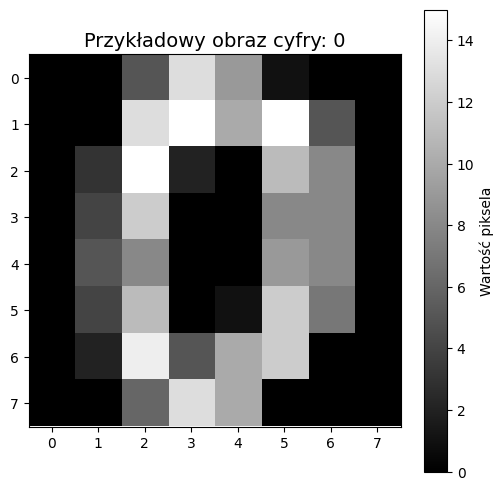

In [31]:
# 2.1.2. Przygotowanie ramki danych piksele
df_pixels = data_digits.drop(columns=['number_label'])

# 2.1.3. Przykładowa reprezentacja obrazu (pierwszy wiersz danych)
example_image = df_pixels.iloc[0].values.reshape(8, 8)

# 2.1.4. Wizualizacja obrazu
plt.figure(figsize=(6, 6))
plt.imshow(example_image, cmap='gray', interpolation='nearest')
plt.title("Przykładowy obraz cyfry: 0", fontsize=14)
plt.colorbar(label='Wartość piksela')
plt.show()

##### 2.2. Implementacja PCA: 
##### 2.2.1. Standaryzacja danych. 
##### 2.2.2. Redukcja wymiarowości do 2 składowych głównych (rzutowanie przestrzeni 64-wymiarowej na przestrzeń dwuwymiarową). 
##### 2.2.3. Dopasowanie  PCA  do  danych  –  dopasowanie  transformatora  PCA  do  zestawu danych, w celu uzyskania dwóch głównych składowych. 
##### 2.2.4. Wyświetlenie atrybutu components_  
##### 2.2.5. Wariancja poszczególnych składowych – należy sprawdzić, ile wariancji wyjaśnia każda z głównych składowych. 

In [32]:
# 2.2.1. Standaryzacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pixels)

# 2.2.2. Redukcja wymiarowości do 2 składowych głównych
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2.2.3. Dopasowanie PCA do danych
explained_variance_ratio = pca.explained_variance_ratio_
principal_components = pca.components_

# 2.2.4. Wyświetlenie macierzy components_
components_df = pd.DataFrame(principal_components, columns=df_pixels.columns, index=['PCA1', 'PCA2'])
print("Macierz składowych głównych:")
print(components_df)

# 2.2.5. Wariancja poszczególnych składowych
print("\nWariancja wyjaśniona przez PCA1:", explained_variance_ratio[0])
print("Wariancja wyjaśniona przez PCA2:", explained_variance_ratio[1])

Macierz składowych głównych:
      pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
PCA1       -0.0   0.182234   0.285868   0.220370  -0.025170  -0.009497   
PCA2        0.0   0.047027   0.059565  -0.020804   0.155903   0.274133   

      pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
PCA1  -0.052476  -0.062695   0.034707   0.245534  ...   0.121247   0.048771   
PCA2   0.249733   0.145832  -0.001027   0.027619  ...  -0.257752  -0.115002   

      pixel_7_0  pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  \
PCA1  -0.001836   0.160396   0.279853   0.194449   0.017774   0.103198   
PCA2   0.004883   0.044498   0.081400  -0.009905  -0.251934  -0.242618   

      pixel_7_6  pixel_7_7  
PCA1   0.119811   0.071494  
PCA2  -0.165089  -0.071329  

[2 rows x 64 columns]

Wariancja wyjaśniona przez PCA1: 0.12033916097734909
Wariancja wyjaśniona przez PCA2: 0.09561054403097902


##### 2.2.6. Wariancja dwóch składowych – określenie, ile całkowitej wariancji wyjaśniają dwie składowe. 
##### 2.2.7. Liczba składowych dla 95% i 99% wariancji – wyznaczenie liczby składowych potrzebnych do wyjaśnienia odpowiednio 95% i 99% wariancji. 
##### 2.2.8. Wizualizacja rozrzutu cyfr w dwuwymiarowej przestrzeni PCA – utwórz wykres rozrzutu, na którym cyfry są oznaczone kolorami lub etykietami na podstawie kolumny 'number_label'. 


Łączna wariancja wyjaśniona przez PCA1 i PCA2: 0.2159497050083281

Liczba składowych dla 95% wariancji: 40
Liczba składowych dla 99% wariancji: 54


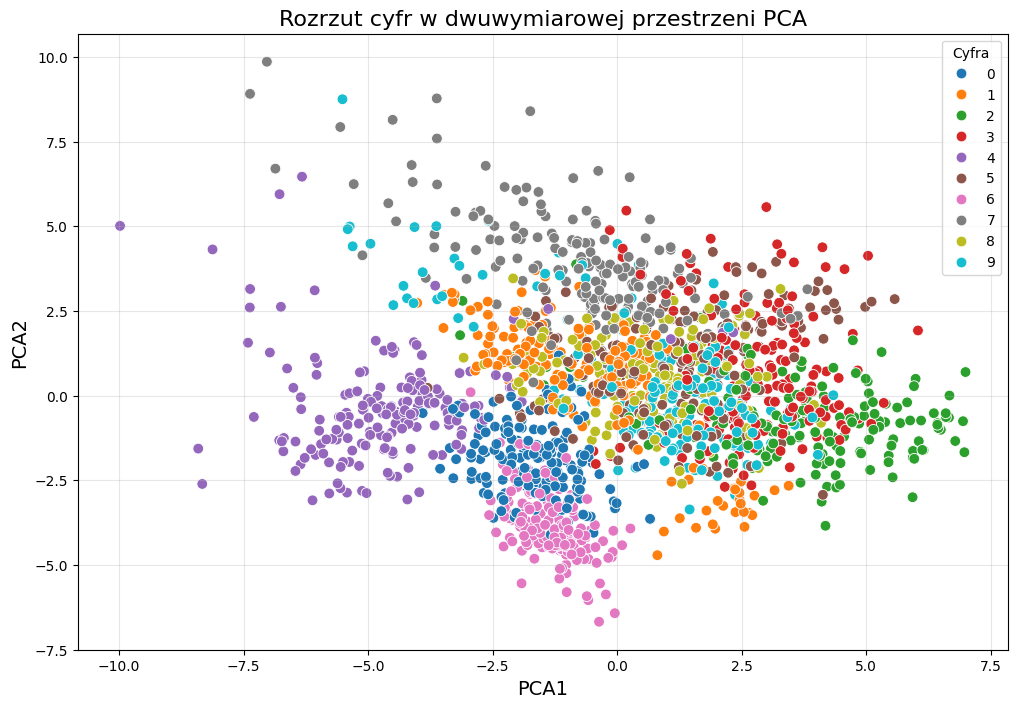

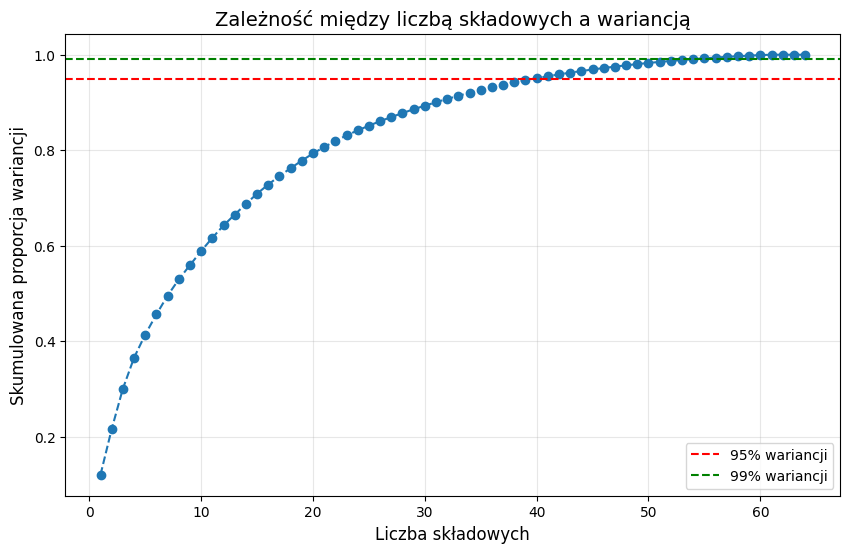

In [ ]:
# 2.2.6. Wariancja dwóch składowych
total_variance_explained = explained_variance_ratio.sum()
print("\nŁączna wariancja wyjaśniona przez PCA1 i PCA2:", total_variance_explained)

# 2.2.7. Liczba składowych dla 95% i 99% wariancji
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance_ratio = pca_full.explained_variance_ratio_.cumsum()

n_components_95 = (cumulative_variance_ratio >= 0.95).argmax() + 1
n_components_99 = (cumulative_variance_ratio >= 0.99).argmax() + 1

print("\nLiczba składowych dla 95% wariancji:", n_components_95)
print("Liczba składowych dla 99% wariancji:", n_components_99)

# 2.2.8. Wizualizacja rozrzutu cyfr w dwuwymiarowej przestrzeni PCA
labels = data_digits['number_label']
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10', legend='full', s=60)
plt.title("Rozrzut cyfr w dwuwymiarowej przestrzeni PCA", fontsize=16)
plt.xlabel("PCA1", fontsize=14)
plt.ylabel("PCA2", fontsize=14)
plt.legend(title="Cyfra", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# Wykres wykres wariancji od liczby składowych
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% wariancji')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% wariancji')
plt.title('Zależność między liczbą składowych a wariancją', fontsize=14)
plt.xlabel('Liczba składowych', fontsize=12)
plt.ylabel('Skumulowana proporcja wariancji', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


2.2.9. Analiza rozróżnialności cyfr
Na wykresie rozrzutu w przestrzeni PCA widać, że cyfry takie jak 4 i 6 są lepiej odseparowane od pozostałych grup.
Cyfry takie jak 5, 3, i 9 nakładają się znacząco na inne klasy, co utrudnia ich rozróżnienie.
2.2.10. Możliwość klasyfikacji
Model kNN:
Dokładność klasyfikacji wynosi 55%, co sugeruje, że dwie główne składowe nie są wystarczające do precyzyjnej klasyfikacji cyfr.
Cyfry 4 i 6 są lepiej klasyfikowane (F1-score ~0.9), podczas gdy cyfry 5, 8, i 9 są klasyfikowane bardzo słabo (F1-score ~0.2–0.3).

### 2.3. Rozszerzenie PCA na trzy składowe główne: 
##### 2.3.1. PCA dla 3 składowych – wykonanie PCA na tym samym zbiorze danych, dla liczby składowych ustawionych na 3. 
##### 2.3.2. Wariancja poszczególnych składowych – sprawdzenie wariancji wyjaśnianej przez każdą z trzech głównych składowych. 
##### 2.3.3. Wariancja dla trzech składowych – ile całkowitej wariancji wyjaśniają trzy główne składowe? 
##### 2.3.4. Wizualizacja w 3D – utworzenie wykresu 3D dla zbioru danych w przestrzeni trzech głównych składowych PCA, na którym cyfry są oznaczone kolorami lub etykietami na podstawie kolumny 'number_label'. 
##### 2.3.5. Analiza rozróżnialności cyfr – określenie, które cyfry są najlepiej rozróżnialne, a które najsłabiej.

Wariancja wyjaśniona przez PCA1, PCA2, PCA3:
PCA1: 0.1203, PCA2: 0.0956, PCA3: 0.0844

Łączna wariancja wyjaśniona przez 3 składowe: 0.3004


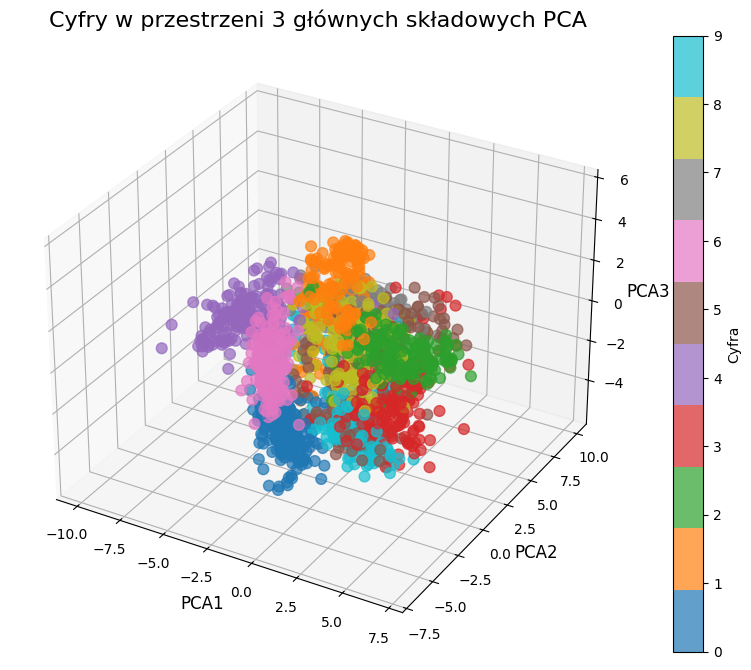

In [36]:
# 2.3.1. PCA dla 3 składowych
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

# 2.3.2. Wariancja poszczególnych składowych
explained_variance_ratio_3 = pca_3.explained_variance_ratio_
print("Wariancja wyjaśniona przez PCA1, PCA2, PCA3:")
print(f"PCA1: {explained_variance_ratio_3[0]:.4f}, PCA2: {explained_variance_ratio_3[1]:.4f}, PCA3: {explained_variance_ratio_3[2]:.4f}")

# 2.3.3. Wariancja dla trzech składowych
total_variance_explained_3 = explained_variance_ratio_3.sum()
print(f"\nŁączna wariancja wyjaśniona przez 3 składowe: {total_variance_explained_3:.4f}")

# 2.3.4. Wizualizacja w 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c=labels, cmap='tab10', s=60, alpha=0.7)

ax.set_title("Cyfry w przestrzeni 3 głównych składowych PCA", fontsize=16)
ax.set_xlabel("PCA1", fontsize=12)
ax.set_ylabel("PCA2", fontsize=12)
ax.set_zlabel("PCA3", fontsize=12)
plt.colorbar(scatter, ax=ax, label='Cyfra')
plt.show()

#2.3.5

#najlepiej: 1 i 4, najgorzej:  8, 3, i 9


2.4.  Przeprowadzenie  PCA  na  danych  oryginalnych  (od  kroku  punktu  2.2.  kroku  2.2.2 
pomijając standaryzację, do punktu 2.3. włącznie).

Macierz składowych głównych (bez standaryzacji):
      pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
PCA1        0.0  -0.017309  -0.223429  -0.135913  -0.033032  -0.096634   
PCA2        0.0   0.010106   0.049085   0.009433   0.053602   0.117755   

      pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
PCA1  -0.008329   0.002269  -0.000321  -0.119309  ...  -0.063288   0.000962   
PCA2   0.062128   0.007936   0.000163   0.021017  ...  -0.148776  -0.000542   

      pixel_7_0  pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  \
PCA1   0.000010  -0.014079  -0.235675  -0.141226  -0.009160  -0.089418   
PCA2   0.000033   0.010079   0.070272  -0.017111  -0.194296  -0.176697   

      pixel_7_6  pixel_7_7  
PCA1  -0.036598  -0.011468  
PCA2  -0.019455   0.006697  

[2 rows x 64 columns]

Wariancja wyjaśniona przez PCA1 (bez standaryzacji): 0.1489059358406385
Wariancja wyjaśniona przez PCA2 (bez standaryzacji): 0.13618771239635438

Łączna war

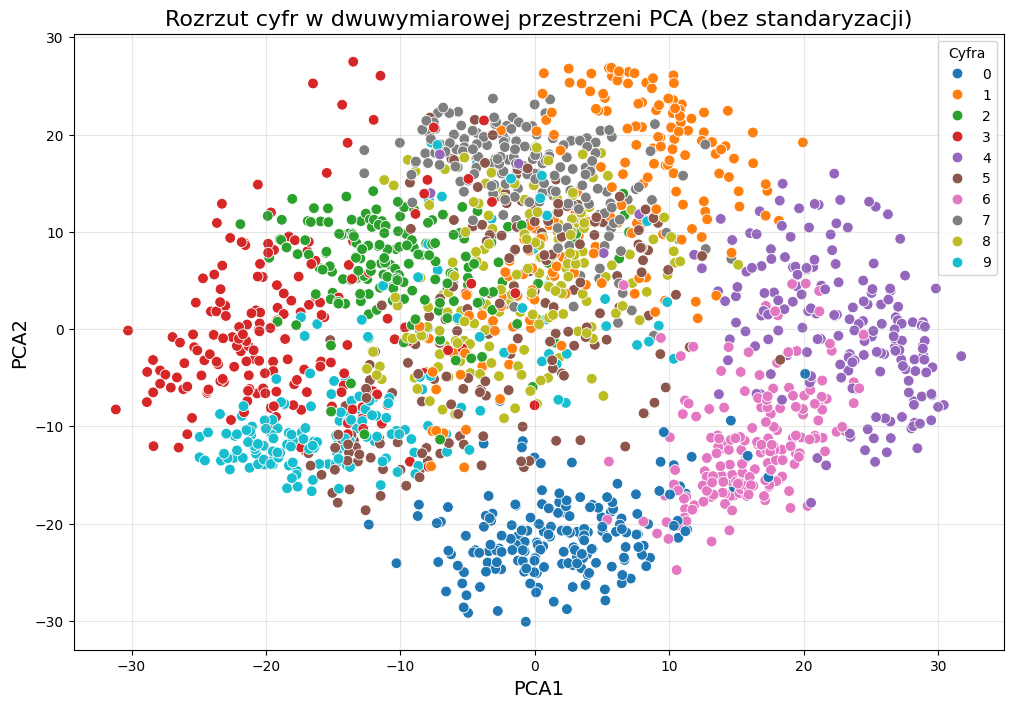


Wariancja wyjaśniona przez PCA1 (bez standaryzacji): 0.1489059358406385
Wariancja wyjaśniona przez PCA2 (bez standaryzacji): 0.13618771239635438
Wariancja wyjaśniona przez PCA3 (bez standaryzacji): 0.11794593763975789

Łączna wariancja wyjaśniona przez PCA1, PCA2 i PCA3 (bez standaryzacji): 0.4030395858767508


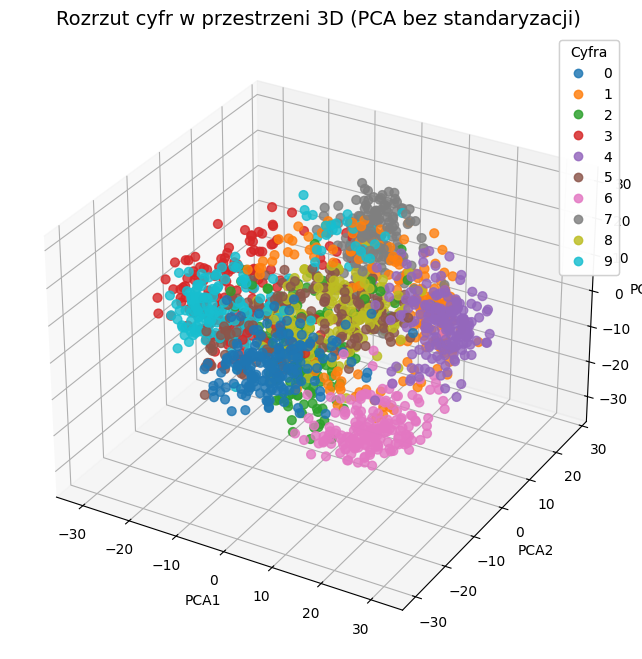

In [42]:
# 2.2.2. Redukcja wymiarowości do 2 składowych głównych (bez standaryzacji)
pca_no_scaling_2d = PCA(n_components=2)
X_pca_no_scaling_2d = pca_no_scaling_2d.fit_transform(df_pixels)

# 2.2.3. Dopasowanie PCA do danych - główne składowe
principal_components_no_scaling_2d = pca_no_scaling_2d.components_

# 2.2.4. Wyświetlenie atrybutu components_
components_df_no_scaling_2d = pd.DataFrame(principal_components_no_scaling_2d, 
                                           columns=df_pixels.columns, 
                                           index=['PCA1', 'PCA2'])
print("Macierz składowych głównych (bez standaryzacji):")
print(components_df_no_scaling_2d)

# 2.2.5. Wariancja poszczególnych składowych
explained_variance_no_scaling_2d = pca_no_scaling_2d.explained_variance_ratio_
print("\nWariancja wyjaśniona przez PCA1 (bez standaryzacji):", explained_variance_no_scaling_2d[0])
print("Wariancja wyjaśniona przez PCA2 (bez standaryzacji):", explained_variance_no_scaling_2d[1])

# 2.2.6. Wariancja dwóch składowych
total_variance_no_scaling_2d = explained_variance_no_scaling_2d.sum()
print("\nŁączna wariancja wyjaśniona przez PCA1 i PCA2 (bez standaryzacji):", total_variance_no_scaling_2d)

# 2.2.7. Liczba składowych dla 95% i 99% wariancji
pca_full_no_scaling = PCA()
pca_full_no_scaling.fit(df_pixels)
cumulative_variance_ratio_no_scaling = pca_full_no_scaling.explained_variance_ratio_.cumsum()

n_components_95_no_scaling = (cumulative_variance_ratio_no_scaling >= 0.95).argmax() + 1
n_components_99_no_scaling = (cumulative_variance_ratio_no_scaling >= 0.99).argmax() + 1

print("\nLiczba składowych dla 95% wariancji (bez standaryzacji):", n_components_95_no_scaling)
print("Liczba składowych dla 99% wariancji (bez standaryzacji):", n_components_99_no_scaling)

# 2.2.8. Wizualizacja rozrzutu cyfr w dwuwymiarowej przestrzeni PCA (bez standaryzacji)
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca_no_scaling_2d[:, 0], y=X_pca_no_scaling_2d[:, 1], hue=labels, 
                palette='tab10', legend='full', s=60)
plt.title("Rozrzut cyfr w dwuwymiarowej przestrzeni PCA (bez standaryzacji)", fontsize=16)
plt.xlabel("PCA1", fontsize=14)
plt.ylabel("PCA2", fontsize=14)
plt.legend(title="Cyfra", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# 2.2.9 i 2.2.10
# Najlepiej rozróżnialne cyfry to 0, 6, i 9, ponieważ tworzą wyraźnie odseparowane klastry.
# Najsłabiej rozróżnialne cyfry to 3, 5, i 8, które znacząco nakładają się na inne klasy.
# Dwie główne składowe PCA pozwalają rozróżnić niektóre cyfry, ale nie są wystarczające 
# do precyzyjnej klasyfikacji wszystkich cyfr, szczególnie tych o podobnych kształtach.

# 2.3.1. PCA dla 3 składowych (bez standaryzacji)
pca_no_scaling_3d = PCA(n_components=3)
X_pca_no_scaling_3d = pca_no_scaling_3d.fit_transform(df_pixels)

# 2.3.2. Wariancja poszczególnych składowych (bez standaryzacji)
explained_variance_no_scaling_3d = pca_no_scaling_3d.explained_variance_ratio_
print("\nWariancja wyjaśniona przez PCA1 (bez standaryzacji):", explained_variance_no_scaling_3d[0])
print("Wariancja wyjaśniona przez PCA2 (bez standaryzacji):", explained_variance_no_scaling_3d[1])
print("Wariancja wyjaśniona przez PCA3 (bez standaryzacji):", explained_variance_no_scaling_3d[2])

# 2.3.3. Wariancja dla trzech składowych (bez standaryzacji)
total_variance_no_scaling_3d = explained_variance_no_scaling_3d.sum()
print("\nŁączna wariancja wyjaśniona przez PCA1, PCA2 i PCA3 (bez standaryzacji):", total_variance_no_scaling_3d)

# 2.3.4. Wizualizacja w 3D (bez standaryzacji)
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
scatter_no_scaling_3d = ax.scatter(X_pca_no_scaling_3d[:, 0], X_pca_no_scaling_3d[:, 1], X_pca_no_scaling_3d[:, 2],
                                   c=labels, cmap='tab10', s=40, alpha=0.8)
legend_no_scaling_3d = ax.legend(*scatter_no_scaling_3d.legend_elements(), title="Cyfra", fontsize=10)
ax.add_artist(legend_no_scaling_3d)
ax.set_title("Rozrzut cyfr w przestrzeni 3D (PCA bez standaryzacji)", fontsize=14)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.show()

# 2.3.5.

# Najlepiej rozróżnialne cyfry to 0, 6, i 9. Tworzą wyraźne, dobrze odseparowane klastry w przestrzeni 3D.
# Najsłabiej rozróżnialne cyfry to 3, 5, i 8. Ich punkty nakładają się na inne cyfry, co utrudnia ich jednoznaczne odseparowanie.
# Dodanie trzeciej składowej poprawia separację klas, ale cyfry o podobnych kształtach wciąż mają trudności z rozróżnieniem. 
# Widać jednak większą poprawę względem przestrzeni 2D.


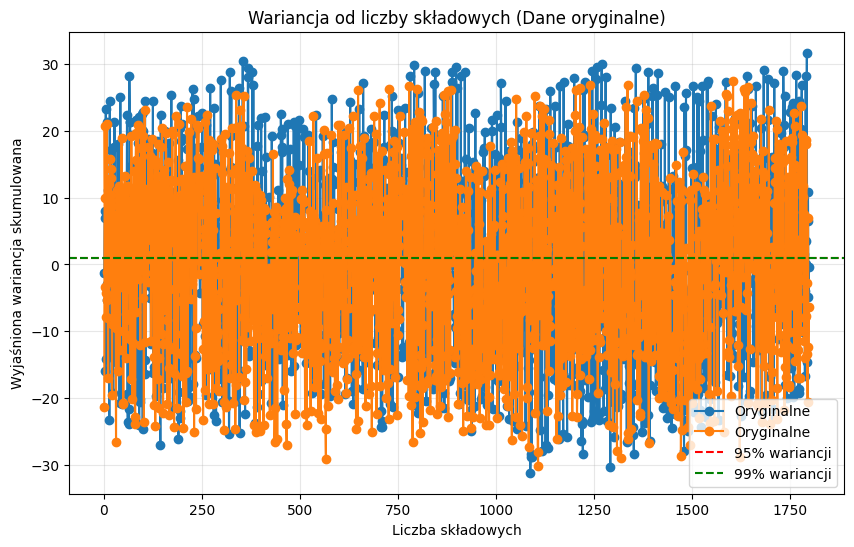

In [45]:
# # Generowanie wykresów wariancji dla danych zestandaryzowanych i oryginalnych z poprawionym kodem

# # Wykres dla danych zestandaryzowanych
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, len(explained_variance_standardized) + 1), explained_variance_standardized, marker='o', label='Zestandaryzowane')
# plt.axhline(0.95, color='r', linestyle='--', label='95% wariancji')
# plt.axhline(0.99, color='g', linestyle='--', label='99% wariancji')
# plt.title('Wariancja od liczby składowych (Dane zestandaryzowane)')
# plt.xlabel('Liczba składowych')
# plt.ylabel('Wyjaśniona wariancja skumulowana')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# Wykres dla danych oryginalnych
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(X_pca_no_scaling_2d) + 1), X_pca_no_scaling_2d, marker='o', label='Oryginalne')
plt.axhline(0.95, color='r', linestyle='--', label='95% wariancji')
plt.axhline(0.99, color='g', linestyle='--', label='99% wariancji')
plt.title('Wariancja od liczby składowych (Dane oryginalne)')
plt.xlabel('Liczba składowych')
plt.ylabel('Wyjaśniona wariancja skumulowana')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
